Paquetes necesarios

In [6]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageSequence

Variables importantes

In [2]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg')              # foto del mandril (bgr)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # mandril en escala de grises
canny = cv2.Canny(gris, 100, 200)            # detección de contornos del mandril con canny

ggris = cv2.GaussianBlur(gris, (3, 3), 0)    # gaussiana
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # sobel x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # sobel y
sobel = cv2.add(sobelx, sobely)              # sobel total

---

### **TAREA 1**

Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

(0.0, 512.0)

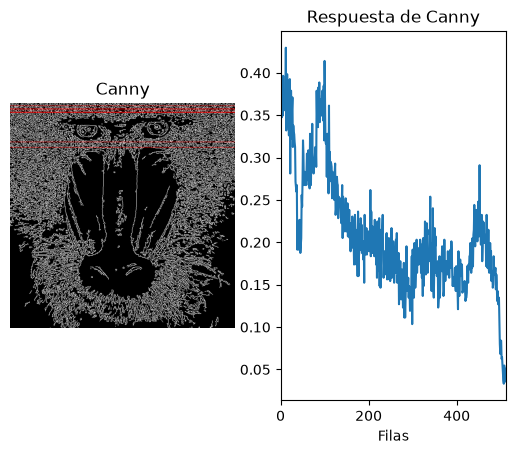

In [3]:
# Cuenta el número de píxeles blancos (255) por columna
# Suma los valores de los pixeles por columna
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Normaliza en base al número de filas y al valor máximo del píxel (255)
# El resultado será el número de píxeles blancos por columna
rows = row_counts[:,0] / (255 * canny.shape[1])

max_value = np.max(rows)
highlight = np.where(rows >= max_value*0.9)[0]

canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
for i in highlight:
    cv2.line(canny_rgb, (0, i), (canny.shape[1], i), (255, 0, 0))


plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny_rgb, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)

#Rango en y definido por las filas
plt.xlim([0, canny.shape[0]])


---

### **TAREA 2**
Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobel tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

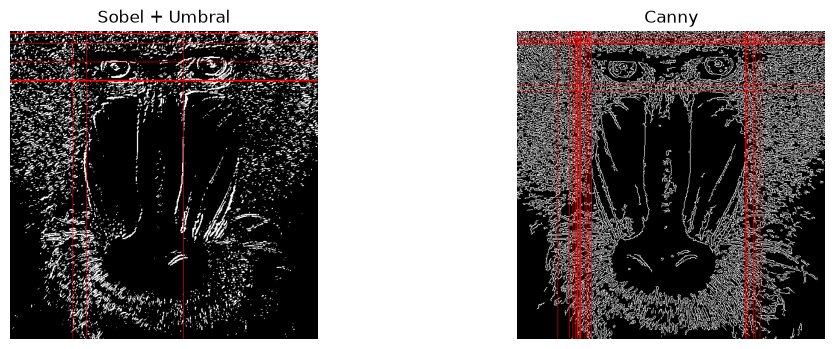

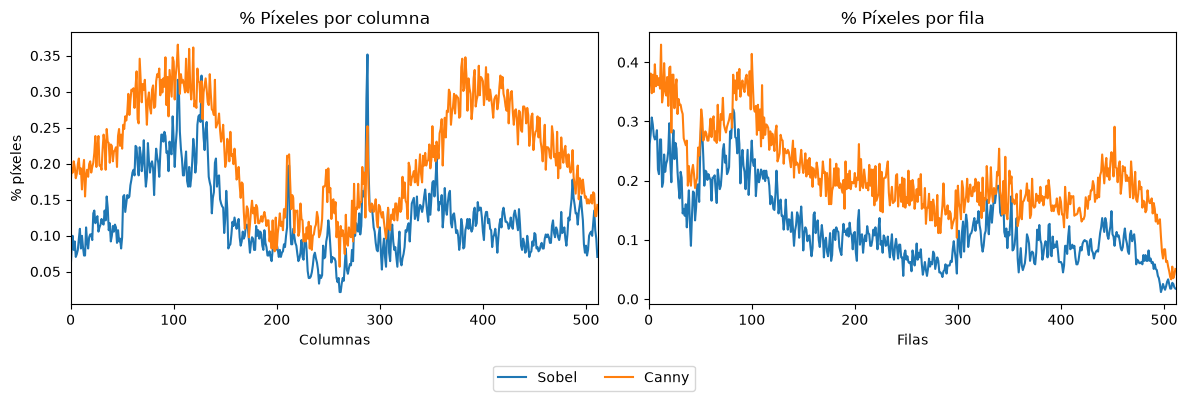

In [4]:
sobel_abs = cv2.convertScaleAbs(sobel)
_, sobel_thresh = cv2.threshold(sobel_abs, 128, 255, cv2.THRESH_BINARY)

col_counts = cv2.reduce(sobel_thresh, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_sobel = col_counts[0] / (255 * sobel_thresh.shape[0])

row_counts = cv2.reduce(sobel_thresh, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
rows_sobel = row_counts[:, 0] / (255 * sobel_thresh.shape[1])


max_row = np.max(rows_sobel)
highlight_rows = np.where(rows_sobel >= max_row*0.9)[0]

max_col = np.max(cols_sobel)
highlight_cols = np.where(cols_sobel >= max_col*0.9)[0]


sobel_rgb = cv2.cvtColor(sobel_thresh, cv2.COLOR_GRAY2RGB)

for y in highlight_rows:
    cv2.line(sobel_rgb, (0, y), (sobel_rgb.shape[1], y), (255, 0, 0))

for x in highlight_cols:
    cv2.line(sobel_rgb, (x, 0), (x, sobel_rgb.shape[0]), (255, 0, 0))



# ======== Canny ====================================================
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols = col_counts[0] / (255 * canny.shape[0])

max_value = np.max(cols)
highlight = np.where(cols > max_value*0.9)[0]

for x in highlight:
    cv2.line(canny_rgb, (x, 0), (x, canny.shape[0]), (255, 0, 0))

# ===============================================================


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel + Umbral")
plt.imshow(sobel_rgb)

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny_rgb) 

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("% Píxeles por columna")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols_sobel, label="Sobel")
plt.plot(cols, label="Canny")
plt.xlim([0, sobel_thresh.shape[1]])

plt.subplot(1, 2, 2)
plt.title("% Píxeles por fila")
plt.xlabel("Filas")
plt.ylabel("")
plt.plot(rows_sobel, label="Sobel")
plt.plot(rows, label="Canny")
plt.xlim([0, sobel_thresh.shape[0]])

handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc="lower center", ncol=2)
plt.tight_layout(rect=[0, 0.08, 1, 1])   # deja hueco abajo para la leyenda
plt.show()


Como se puede observar en los gráficos, por lo general Canny detecta más píxeles blancos que Sobel.
Sin embargo, es destacable que Sobel ocasionalmente conserva un mayor número de píxeles en los bordes verticales.

Se concluye que Canny demuestra una mayor precisión.

---

### **TAREA 3**

Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

#### **Versión 1**

In [13]:
vid = cv2.VideoCapture(0)
bgRemover = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=100, detectShadows=True)


while (True):
    ret, frame = vid.read()

    if ret:
        emarf = cv2.flip(frame, 1)
        bg = bgRemover.apply(emarf)
        _, thresh = cv2.threshold(bg, 128, 255, cv2.THRESH_BINARY)

        col_counts = cv2.reduce(thresh, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
        cols = col_counts[0] / (255 * thresh.shape[0])

        max_value = np.max(cols)
        highlight = np.where(cols > 0.2)[0]

        if len(highlight) > 0:
            x_min, x_max = highlight[0], highlight[-1]
            cv2.rectangle(emarf, (x_min, 0), (x_max, emarf.shape[0]), (0, 0, 0), -1)

        cv2.imshow('Cortina', emarf)
    
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

#### **Versión 2**

In [ ]:
# Cargar gifs

gif = []
with Image.open("./smack-slap.gif") as img:
    for f in ImageSequence.Iterator(img):
        rgb = np.array(f.convert("RGB"))
        gif.append(cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))


vid = cv2.VideoCapture(0)
bgRemover = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=100, detectShadows=True)


gif_frame = 0
while (True):
    ret, frame = vid.read()

    if ret:
        emarf = cv2.flip(frame, 1)
        bg = bgRemover.apply(emarf)
        _, thresh = cv2.threshold(bg, 128, 255, cv2.THRESH_BINARY)

        col_counts = cv2.reduce(thresh, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
        cols = col_counts[0] / (255 * thresh.shape[0])

        max_value = np.max(cols)
        highlight = np.where(cols > 0.2)[0]

        if len(highlight) > 0:
            x = (highlight[0] + highlight[-1])//2
            gif_frame = len(gif) - round((x/frame.shape[1])*len(gif))  # Mapear posición a un frame del gif
            cv2.line(emarf, (x, 0), (x, emarf.shape[0]), (255, 0, 0))
        
        cv2.imshow('Detección', emarf)
        cv2.imshow('Pescado', gif[gif_frame])
    
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()


30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
